# Presentation

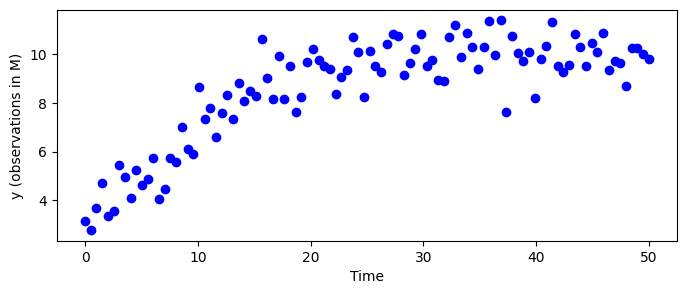

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Time axis
T = 100
t = np.linspace(0, 50, T)

# Logistic trend
K = 10.0      # carrying capacity
r = 0.2      # growth rate
t0 = 5.0     # midpoint
trend = K / (1 + np.exp(-r * (t - t0)))

# Noise
noise_std = 0.9
noise = noise_std * np.random.randn(T)

# Observations in space M
y = trend + noise

# Plot
plt.figure(figsize=(8,3))
plt.scatter(t, y, color='blue')
plt.xlabel("Time")
plt.ylabel("y (observations in M)")
plt.title("")
plt.show()


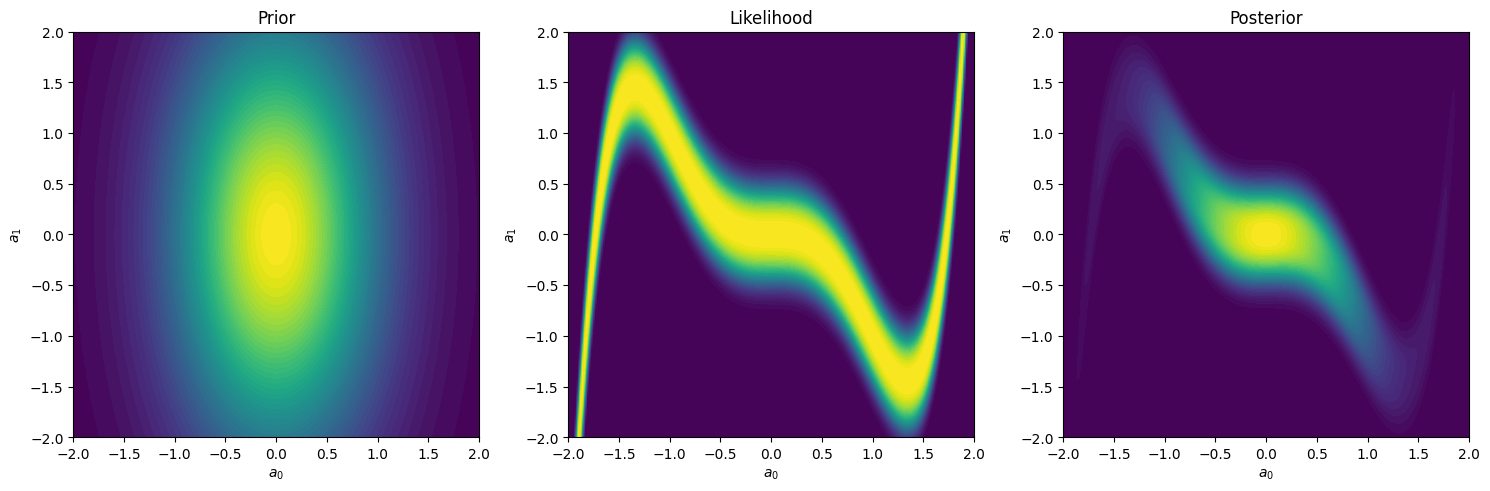

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Grid in parameter space (R^2)
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)
X = np.stack([X1, X2], axis=-1)

# ---- Prior: 2D elliptical Gaussian ----
mu = np.array([0.0, 0.0])
Sigma = np.array([[0.5, 0.0],
                  [0.0, 2.25]])
Sigma_inv = np.linalg.inv(Sigma)

def gaussian_prior(X, mu, Sigma_inv):
    diff = np.abs(X - mu)**1
    expo = np.einsum("...i,ij,...j->...", diff, Sigma_inv, diff)
    return np.exp(-0.5 * expo)

prior = gaussian_prior(X, mu, Sigma_inv)

# ---- Forward model: implicit curve ----
def f(X):
    return X[..., 1] - 0.5*(X[..., 0]**5 - 3*X[..., 0]**3)

# Observation: curve level-set
y_obs = 0.0
sigma2 = 0.05

def likelihood(X, y_obs, sigma2):
    res = np.abs(f(X) - y_obs)
    return np.exp(-0.5 * res**3 / sigma2)


like = likelihood(X, y_obs, sigma2)

# ---- Posterior (unnormalized) ----
posterior = prior * like

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].contourf(X1, X2, prior, levels=50)
axes[0].set_title("Prior")

axes[1].contourf(X1, X2, like, levels=50)
axes[1].set_title("Likelihood")

axes[2].contourf(X1, X2, posterior, levels=50)
axes[2].set_title("Posterior")

for ax in axes:
    ax.set_xlabel("$a_0$")
    ax.set_ylabel("$a_1$")
    ax.set_aspect("equal")

plt.tight_layout()


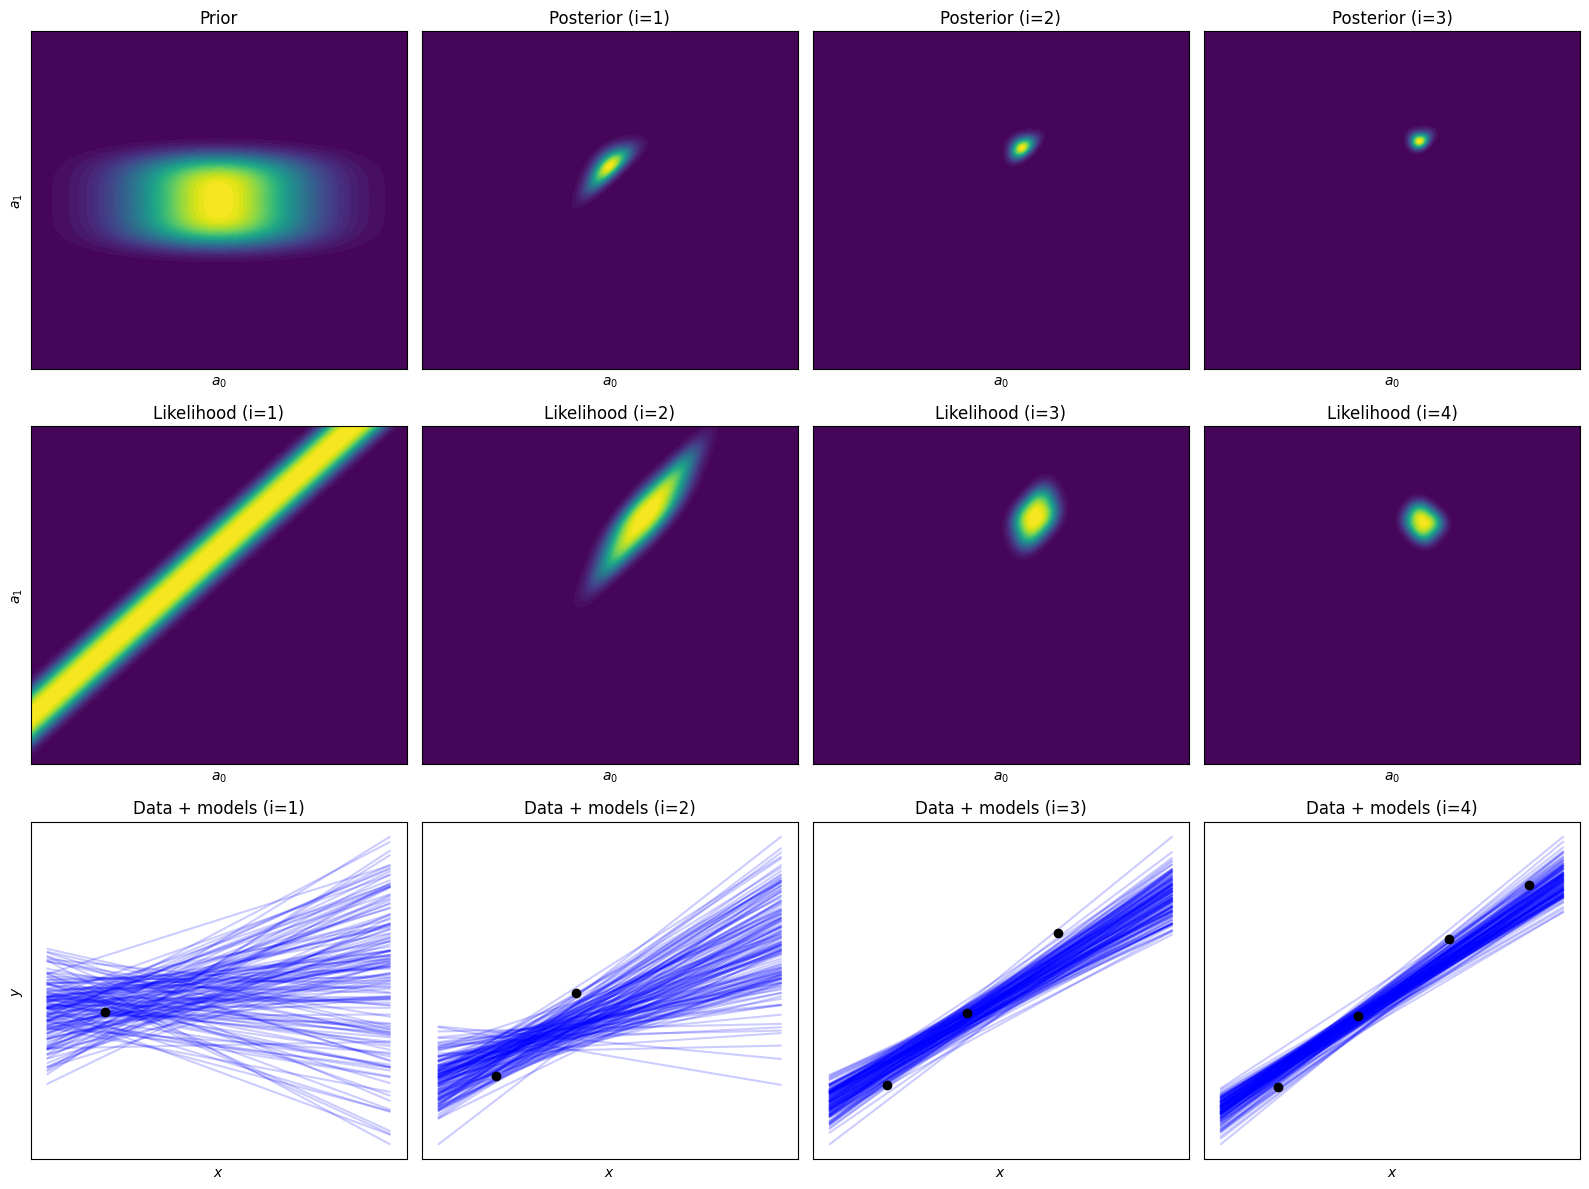

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Parameter space
# --------------------------------------------------
a0 = np.linspace(-3, 3, 300)
a1 = np.linspace(-3, 3, 300)
A0, A1 = np.meshgrid(a0, a1)

# --------------------------------------------------
# Prior (Gaussian)
# --------------------------------------------------
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.1],
                  [0.1, 0.2]])
Sigma_inv = np.linalg.inv(Sigma)

def gaussian_prior(A0, A1):
    diff0 = np.abs(A0 - mu[0])
    diff1 = np.abs(A1 - mu[1])
    quad = Sigma_inv[0,0]*diff0**2 + Sigma_inv[1,1]*diff1**4
    return np.exp(-0.5 * quad)

prior = gaussian_prior(A0, A1)

# --------------------------------------------------
# Synthetic data
# --------------------------------------------------
x_data = np.array([-1.0, -0.3, 0.5, 1.2])
a0_true, a1_true = 0.5, 1.2
y_data = (a0_true + a1_true * x_data) * np.exp(0.20 * np.random.rand(len(x_data)))
sigma2 = 0.05

# --------------------------------------------------
# Likelihood for i data points
# --------------------------------------------------
def likelihood_i(A0, A1, x, y, sigma2):
    ll = np.zeros_like(A0)
    for xi, yi in zip(x, y):
        res = yi - (A0 + A1 * xi)
        ll += np.abs(res)**3
    return np.exp(-0.5 * ll / sigma2)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

x_plot = np.linspace(-1.5, 1.5, 100)

for i in range(1, 5):

    # Likelihood with i points
    like = likelihood_i(A0, A1, x_data[:i], y_data[:i], sigma2)

    # Posterior (unnormalized)
    if i ==1: 
        post = prior * like
    else:
        post = post * like

    # -----------------------------
    # Row 1: Prior / Posterior
    # -----------------------------
    if i == 1:
        axes[0, i-1].contourf(A0, A1, prior, levels=40)
        axes[0, i-1].set_title("Prior")
    else:
        axes[0, i-1].contourf(A0, A1, post, levels=40)
        axes[0, i-1].set_title(f"Posterior (i={i-1})")

    # -----------------------------
    # Row 2: Likelihood
    # -----------------------------
    axes[1, i-1].contourf(A0, A1, like, levels=40)
    axes[1, i-1].set_title(f"Likelihood (i={i})")

    # -----------------------------
    # Row 3: Data + generative models
    # -----------------------------
    axes[2, i-1].scatter(x_data[:i], y_data[:i], color="black", zorder=7)

    # Sample parameter curves from posterior
    # Flatten posterior
    post_flat = post.flatten()
    post_flat /= post_flat.sum()  # normalize

    # Sample indices according to posterior
    idx = np.random.choice(
        A0.size,
        size=150,
        replace=True,
        p=post_flat
    )

    a0_s = A0.flatten()[idx]
    a1_s = A1.flatten()[idx]
    for a0_k, a1_k in zip(a0_s, a1_s):
        y_plot = a0_k + a1_k * x_plot
        axes[2, i-1].plot(x_plot, y_plot, color="blue", alpha=0.2)

    axes[2, i-1].set_title(f"Data + models (i={i})")

    # Formatting
    for r in range(3):
        axes[r, i-1].set_aspect("auto")

for i in range(3):
    for j in range(4):
        axes[i,j].set_xticks([])
        axes[i,j].set_yticks([])
        if i==2:
            axes[i,j].set_xlabel("$x$")
            if j==0:
                axes[i,j].set_ylabel("$y$")
        else: 
            axes[i,j].set_xlabel("$a_0$")
            if j==0:
                axes[i,j].set_ylabel("$a_1$")
        #axes[i,j].set_aspect("equal")
plt.tight_layout()


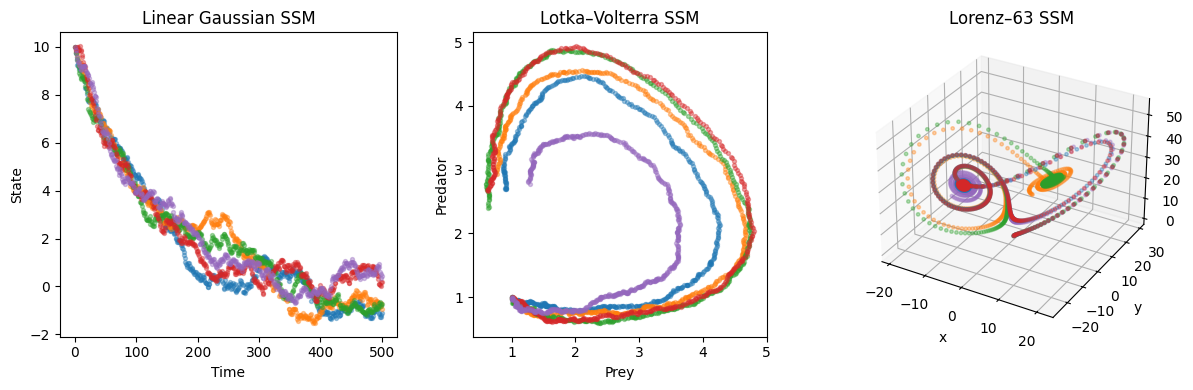

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

import sys
import os
sys.path.append(os.path.abspath(".."))

from Models.linear import LinearGaussianSSM
from Models.lokta_volterra import LotkaVolterraSSM
from Models.lorenz63 import Lorenz63SSM

# -----------------------------
# Parameters
# -----------------------------
T = 500
n_realizations = 5
np.random.seed(123)

# -----------------------------
# Models
# -----------------------------
lgssm = LinearGaussianSSM(
    m0=np.array([10.0]),
    P0=np.array([[0.1]]),
    A=np.array([[0.99]]),
    H=np.array([[0.1]]),
    Sigma=0.01 * np.eye(1),
    Gamma=0.01 * np.eye(1),
)

lvssm = LotkaVolterraSSM()
lorenzssm = Lorenz63SSM()

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2)
ax3 = fig.add_subplot(1, 3, 3, projection="3d")

# -----------------------------
# Linear Gaussian SSM (scatter in time)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lgssm.simulate(T)
    ax1.scatter(
        np.arange(T + 1),
        X[:, 0],
        s=8,
        alpha=0.4
    )

ax1.set_title("Linear Gaussian SSM")
ax1.set_xlabel("Time")
ax1.set_ylabel("State")

# -----------------------------
# Lotka–Volterra (2D phase space)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lvssm.simulate(T)
    ax2.scatter(
        X[:, 0],
        X[:, 1],
        s=8,
        alpha=0.4
    )

ax2.set_title("Lotka–Volterra SSM")
ax2.set_xlabel("Prey")
ax2.set_ylabel("Predator")
ax2.set_aspect("equal")

# -----------------------------
# Lorenz–63 (3D attractor)
# -----------------------------
for _ in range(n_realizations):
    X, _ = lorenzssm.simulate(T)
    ax3.scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        s=6,
        alpha=0.35
    )

ax3.set_title("Lorenz–63 SSM")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
ax3.set_zlabel("z")

plt.tight_layout()
plt.show()
